## Exploratory Data Analysis - Week 4 - Diya Mirji

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#load datasets
sleep_data = pd.read_csv("../data/week4/sleep.csv")
weather_data = pd.read_csv("../data/week4/weather.csv")


In [5]:
sleep_data.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


In [6]:
weather_data.head()

,user_code,day,avg_temperature_C,atmospheric_pressure,precip_intensity,humidity,clouds
0,013f6d3e5b,2020-05-22,18.0667,1017.6,0.0002,70.0,67.0
1,01bad5a519,2020-01-11,-1.2111,1016.4,0.0002,92.0,6.0
2,01bad5a519,2020-01-30,0.5056,1004.7,0.0009,85.0,100.0
3,01bad5a519,2020-04-02,-0.2444,994.4,0.0025,91.0,87.0
4,01bad5a519,2020-04-12,5.1778,1016.1,0.0000,61.0,91.0


In [ ]:
print("Sleep Data Structure")
print("---------------")
print(f"Dimensions: {sleep_data.shape}")
print(f"Data Types:\n{sleep_data.dtypes}")
print(f"Missing Values:\n{sleep_data.isnull().sum()}")

Sleep Data Structure
---------------
Dimensions: (425, 12)
Data Types:
user_code                object
day                      object
sleep_begin              object
sleep_end                object
sleep_duration          float64
sleep_awake_duration    float64
sleep_rem_duration      float64
sleep_light_duration    float64
sleep_deep_duration     float64
pulse_min               float64
pulse_max               float64
pulse_average           float64
dtype: object
Missing Values:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64


Sleep Data Interpretation

This dataset contains 425 observations and 12 features.

For the categorical features:
   * "user_code" - is a unique id for each user that the data was collected from
   * "day" - is a date object that is formatted as "YYYY-MM-DD" representing the day the data was collected
   * "sleep_begin" - is a datetime object that is formatted as "YYYY-MM-DD HH:MM:SS" representing the datetime the sleep began 
   * "sleep_end" - is a datetime object that is formatted as "YYYY-MM-DD HH:MM:SS" representing the datatime the sleep ended

For the numerical features:
   * "sleep_duration" - is a float representing the duration of the user's sleep on a certain day
   * "sleep_awake_duration" - is a float representing the duration of the user's awake sleep on a certain day
   * "sleep_rem_duration" - is a float representing the duration of the user's rem sleep on a certain day
   * "sleep_light_duration" - is a float representing the duration of the user's light sleep on a certain day
   * "sleep_deep_duration" - is a float representing the duration of the user's deep sleep on a certain day
   * "pulse_min" - is a float representing the user's minimum pulse rate during sleep on a certain day
   * "pulse_max" - is a float representing the user's maximum pulse rate during sleep on a certain day
   * "pulse_average" - is a float representing the user's average pulse rate during sleep on a certain day

The dataset is not complete. While it has no missing values for "user_code", "day", "sleep_begin", "sleep_end", and "sleep_duration", there are a lot of missing values for the rest of the features. Since the missing values in the rest of the features are a large amount compared to the total observations (ex: 416/425), the features will need to be removed.


In [9]:
print("Weather Data Structure")
print("---------------")
print(f"Dimensions: {weather_data.shape}")
print(f"Data Types:\n{weather_data.dtypes}")
print(f"Missing Values:\n{weather_data.isnull().sum()}")

Weather Data Structure
---------------
Dimensions: (1717, 7)
Data Types:
user_code                object
day                      object
avg_temperature_C       float64
atmospheric_pressure    float64
precip_intensity        float64
humidity                float64
clouds                  float64
dtype: object
Missing Values:
user_code               0
day                     0
avg_temperature_C       0
atmospheric_pressure    0
precip_intensity        0
humidity                0
clouds                  0
dtype: int64


Weather Data Interpretation

This dataset contains 1717 observations and 7 features.

For the categorical features:
   * "user_code" - is a unique id for each user that the data was collected from
   * "day" - is a date object that is formatted as "YYYY-MM-DD" representing the day the data was collected

For the numerical features:
   * "avg_temperature_C" - is a float representing the average temperature in Celsius that was collected from user on a certain day
   * "atmospheric_pressure" - is a float representing the atmospheric pressure that was collected from user on a certain day
   * "precip_intensity" - is a float representing the precipitation intensity that was collected from user on a certain day
   * "humidity" - is a float representing the humidity(%) that was collected from user on a certain day
   * "clouds" - is a float representing the cloudiness(%) that was collected from user on a certain day

The dataset is complete.


In [10]:
# Descriptive Statistics
print("\nDescriptive Statistics for Sleep Data")
print("----------------------")
numeric_columns = sleep_data.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(sleep_data[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(sleep_data[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures for Sleep Data:")
print("------------------------")
print(sleep_data[numeric_columns].skew())
print(sleep_data[numeric_columns].kurt())


Descriptive Statistics for Sleep Data
----------------------
Central Tendency Measures:
      sleep_duration  sleep_awake_duration  sleep_rem_duration  \
mean    25699.731765           2733.333333         6518.571429   
50%     26041.000000           2490.000000         6240.000000   

      sleep_light_duration  sleep_deep_duration  pulse_min  pulse_max  \
mean          14514.740741          4280.285714  60.533333  89.866667   
50%           17340.000000          4230.000000  58.000000  93.000000   

      pulse_average  
mean      68.880733  
50%       65.857000  

Dispersion Measures:
     sleep_duration  sleep_awake_duration  sleep_rem_duration  \
std      7773.80547             671.90029         2081.613385   
min       930.00000            1740.00000         2820.000000   
max     47460.00000            4200.00000         8730.000000   

     sleep_light_duration  sleep_deep_duration   pulse_min   pulse_max  \
std            8078.12629          2089.766547   12.844491   10.54152

Interpretation of Descriptive Statistics for Sleep Data

Central Tendency Measures:
The mean and median(50%) provide insights into the central location of the data. For example, the mean sleep duration is around 25699, and the median is around 26041, indicating a roughly symmetric distribution. But there is a skewed distribution for awake sleep duration. 

Dispersion Measures:
These measures give us an understanding of the spread and range of the data. For instance, the standard deviation of sleep duration is about 7773, indicating the typical deviation from the mean 25699.

Distribution Measures:
Skewness values close to 0 indicate a symmetric distribution, while positive or negative values indicate right or left skew, respectively. Kurtosis indicates the "tailedness" of the distribution; values close to 0 suggest a normal distribution, while higher values suggest heavier tails. For example, the skewness of sleep duration is -0.564 that indicates a symmetric distribution with a left skew. And the kurtosis of sleep duration is 0.827 that indicates a normal distribution.

In [11]:
# Descriptive Statistics
print("\nDescriptive Statistics for Weather Data")
print("----------------------")
numeric_columns = weather_data.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(weather_data[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(weather_data[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures for Weather Data:")
print("------------------------")
print(weather_data[numeric_columns].skew())
print(weather_data[numeric_columns].kurt())


Descriptive Statistics for Weather Data
----------------------
Central Tendency Measures:
      avg_temperature_C  atmospheric_pressure  precip_intensity   humidity  \
mean          11.839221           1014.111639          0.003803  66.376586   
50%           11.272200           1014.100000          0.000200  68.000000   

         clouds  
mean  56.401734  
50%   61.500000  

Dispersion Measures:
     avg_temperature_C  atmospheric_pressure  precip_intensity   humidity  \
std           7.769565              8.356792          0.015348   19.33967   
min         -13.150000            984.300000          0.000000    3.00000   
max          44.072200           1047.750000          0.256700  100.00000   

         clouds  
std   35.048917  
min    0.000000  
max  100.000000  

Distribution Measures for Weather Data:
------------------------
avg_temperature_C       0.355088
atmospheric_pressure   -0.077967
precip_intensity        9.555513
humidity               -0.571713
clouds             

Interpretation of Descriptive Statistics for Weather Data

Central Tendency Measures:
The mean and median(50%) provide insights into the central location of the data. For example, the mean average temperature is around 11.839 C, and the median is around 11.272 C, indicating a roughly symmetric distribution.

Dispersion Measures:
These measures give us an understanding of the spread and range of the data. For instance, the standard deviation of average temperature is about 7.769 degrees, indicating the typical deviation from the mean 11.839 C.

Distribution Measures:
Skewness values close to 0 indicate a symmetric distribution, while positive or negative values indicate right or left skew, respectively. Kurtosis indicates the "tailedness" of the distribution; values close to 0 suggest a normal distribution, while higher values suggest heavier tails. For example, the skewness of average temperature is 0.355 that indicates a symmetric distribution with a right skew. And the kurtosis of sleep duration is 0.392 that indicates a normal distribution.


Variable Relationships for Sleep Data
----------------------
Correlation Matrix:
                      sleep_duration  sleep_awake_duration  \
sleep_duration              1.000000             -0.176436   
sleep_awake_duration       -0.176436              1.000000   
sleep_rem_duration          0.962985             -0.382577   
sleep_light_duration        0.409195              0.466358   
sleep_deep_duration         0.551536              0.283719   
pulse_min                   0.286882             -0.937728   
pulse_max                   0.542304             -0.999860   
pulse_average               0.243608             -0.935125   

                      sleep_rem_duration  sleep_light_duration  \
sleep_duration                  0.962985              0.409195   
sleep_awake_duration           -0.382577              0.466358   
sleep_rem_duration              1.000000              0.754172   
sleep_light_duration            0.754172              1.000000   
sleep_deep_duration          

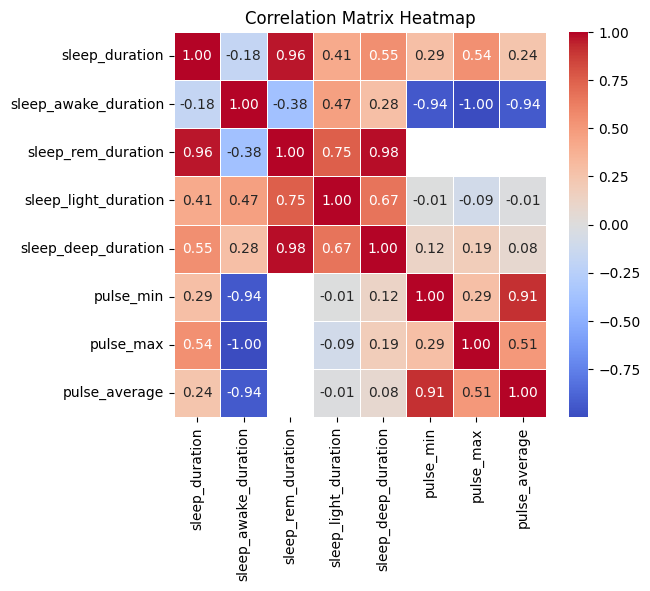

In [15]:
# Variable Relationships
print("\nVariable Relationships for Sleep Data")
print("----------------------")
print("Correlation Matrix:")
numeric_columns = sleep_data.select_dtypes(include=[np.number]).columns
correlation_matrix = sleep_data[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Interpretation of Variable Relationships for Sleep Data

Positive correlation values (close to 1) indicate a strong direct relationship, while negative values (close to -1) indicate an inverse relationship. For example, sleep duration and rem sleep duration have a high positive correlation (0.96), suggesting that as sleep duration increases, rem sleep duration also tends to increase.


Variable Relationships for Weather Data
----------------------
Correlation Matrix:
                      avg_temperature_C  atmospheric_pressure  \
avg_temperature_C              1.000000             -0.002708   
atmospheric_pressure          -0.002708              1.000000   
precip_intensity               0.030620             -0.145488   
humidity                      -0.449895             -0.112873   
clouds                        -0.155868             -0.288340   

                      precip_intensity  humidity    clouds  
avg_temperature_C             0.030620 -0.449895 -0.155868  
atmospheric_pressure         -0.145488 -0.112873 -0.288340  
precip_intensity              1.000000  0.230269  0.209718  
humidity                      0.230269  1.000000  0.399211  
clouds                        0.209718  0.399211  1.000000  


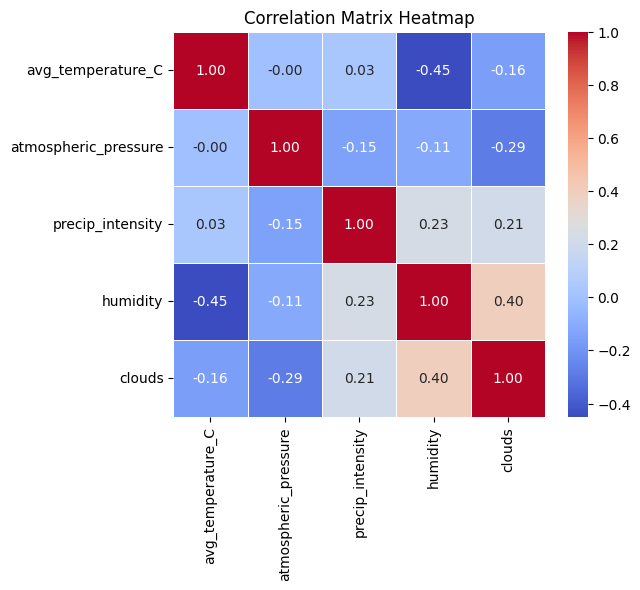

In [17]:
# Variable Relationships
print("\nVariable Relationships for Weather Data")
print("----------------------")
print("Correlation Matrix:")
numeric_columns = weather_data.select_dtypes(include=[np.number]).columns
correlation_matrix = weather_data[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Interpretation of Variable Relationships for Sleep Data

Positive correlation values (close to 1) indicate a strong direct relationship, while negative values (close to -1) indicate an inverse relationship. For example, this correlation matrix shows no strong correlation between particular features.

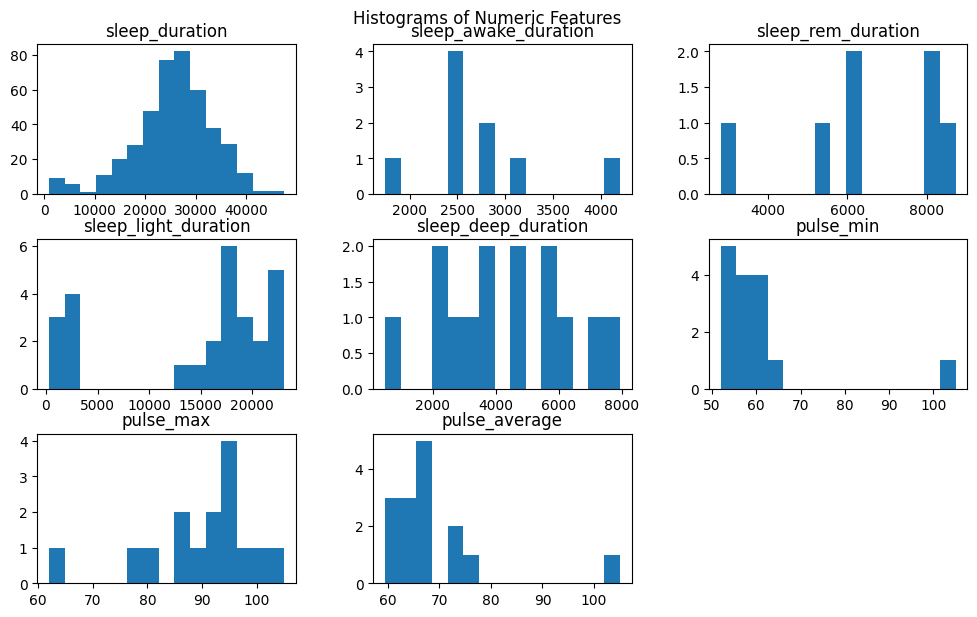

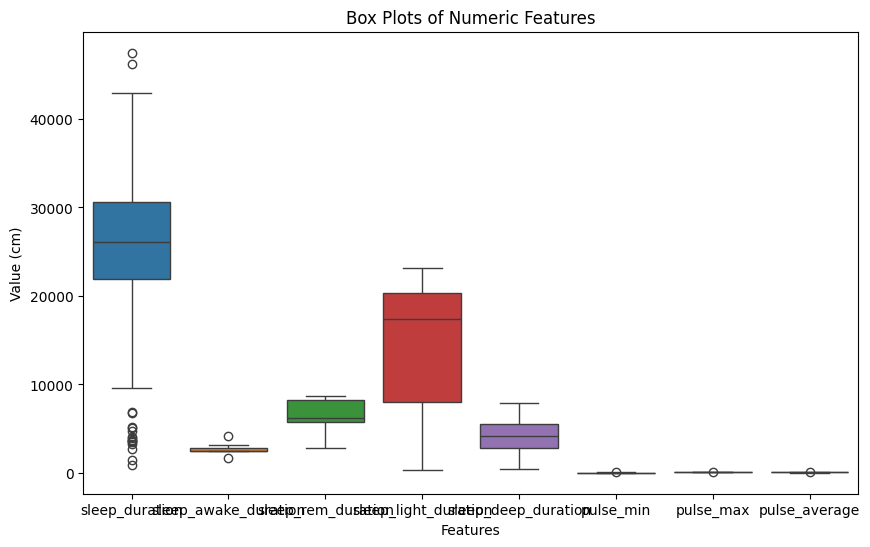

In [29]:
# Data Visualization for Sleep Data
numeric_columns = sleep_data.select_dtypes(include=[np.number]).columns

# Visualize distributions
sleep_data[numeric_columns].hist(bins=15, figsize=(12,7), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=sleep_data[numeric_columns])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value (cm)')
plt.show()

Interpretation of Data Visualization for Sleep Data

Histograms:
Histograms display the distribution of each numerical feature. For example, the histogram of sleep duration shows a normal distribution, indicating a typical spread of values.

Box Plots:
I'm using a box plot to help point out any outliers to test for influence later.
Box plots highlight the spread of the data and potential outliers. For instance, the box plot of sleep duration reveals many outliers close to 0 and 2 outliers above 40000, suggesting some collected sleep durations have unusually short or long sleep durations.

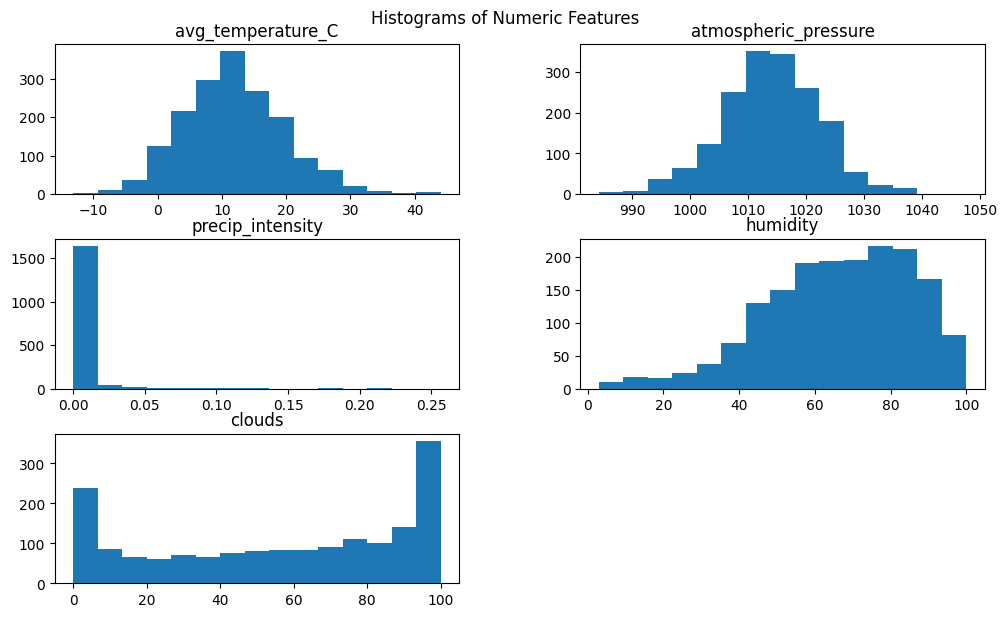

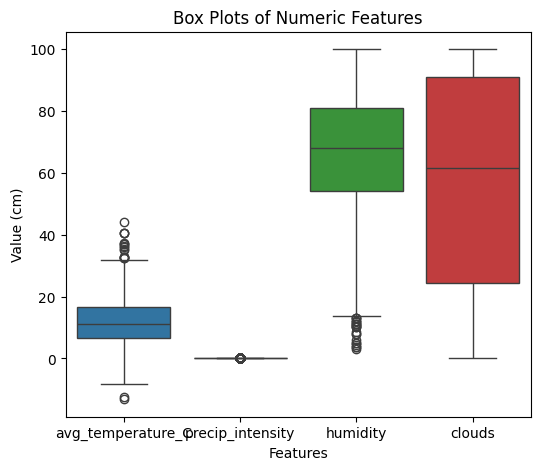

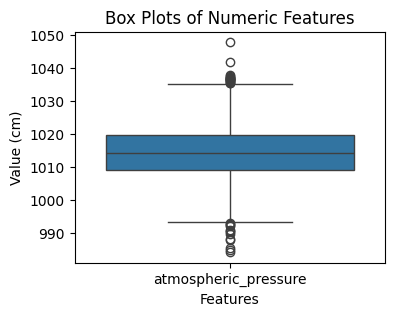

In [35]:
# Data Visualization for Weather Data
numeric_columns = weather_data.select_dtypes(include=[np.number]).columns

# Visualize distributions
weather_data[numeric_columns].hist(bins=15, figsize=(12,7), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(6, 5))
sns.boxplot(data=weather_data[numeric_columns.drop("atmospheric_pressure")])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value (cm)')
plt.show()

plt.figure(figsize=(4, 3))
sns.boxplot(data=weather_data[["atmospheric_pressure"]])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value (cm)')
plt.show()

Interpretation of Data Visualization for Weather Data

Histograms:
I'm using histograms to display the spread of the variables and which way the data skews to show if there are any subgroups for certain features.
Histograms display the distribution of each numerical feature. For example, the histogram of humidity shows a left skewed distribution, indicating a there are more outliers closer to 0.

Box Plots:
Box plots highlight the spread of the data and potential outliers. For instance, the box plot of cloudiness reveals no outliers, suggesting the collected cloudiness is spread wide in variance.

Discussion of Handling Missing Values, Removing Duplicates, and Handling Outliers for Sleep Data

Handling Missing Values:
The sleep data has multiple features that have a majority of missing values as shown in the Sleep Data Structure. 
* sleep_awake_duration    416
* sleep_rem_duration      418
* sleep_light_duration    398
* sleep_deep_duration     411
* pulse_min               410
* pulse_max               410
* pulse_average           410
These features have a missing value rate of above 96% (sum of missing values/total observations). Since the ~4% of data that is actually collected would not be a good representation of all observations if we decided to fill all missing values by an average, it would be smarter to remove these features listed above.

Handling Outliers:
If we remove the features stated above, the only numerical category that we would have to handle for outliers would be for the sleep duration feature. It would be helpful to calculate the Cook's distance (as learned in XAI) for this feature values as an outlier can be shown to have a strong influence on the model. If the outlier observations have too much influence, then it would be smart to remove those observations.

Removing Duplicates:
For this sleep dataset, there are duplicates in the user_code and the day columns because a user can have multiple data observations for multiple days, and a day can have multiple data observations for multiple users. So the unique key for the dataset would be a combination of day and user_code. Therefore, the duplicates in user_code and day cannot be removed. 


For future EDA, 

I would have wanted to join the two data sets by the key user_code and day to create new features. Then, I would test the correlation matrix again to see if any features between the two datasets have a strong correlation. 